[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/00_simulation.ipynb)

# 00 — BandTilt Simulation

## 1. Overview

This notebook builds the synthetic network **BandTilt** is evaluated on: a multi-band antenna tilt
coordination study for coverage-efficient 5G/6G radio access networks. It combines a time-varying UE
population, Sionna-RT ray tracing and the project's KPI and objective definitions, and reports every
measure at the committed (baseline) tilt configuration.

**Inputs.** `configs/simulation.yaml`, `configs/kpi.yaml`.
**Outputs.** `data/external/` (UE positions, scenario manifest), `data/interim/radio_map.npz`,
`data/interim/mdt.csv` (the MDT, kept for later use), and
tables and figures under `reports/`.
**Requirements.** A CUDA GPU for Sionna-RT. The shell equivalent is `task simulation`.
Optimization and the baseline-versus-optimized comparison live in notebooks 03a, 03b and 04.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

import json
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.export import save_table
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/00_simulation"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/00_simulation"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)


def property_table(values, name):
    """A two-column Property/Value table, saved under ``name``."""
    table = pd.DataFrame({"Value": values}).rename_axis("Property").reset_index()
    save_table(table, name)
    return table

## 2. Simulation Objectives

The simulation:

* draws a spatially and temporally varying UE population over the open ground of a 3D city scene;
* ray-traces the received signal power of every cell on every frequency band over a measurement grid;
* assigns each UE a serving cell-band under band preference and PRB limits;
* keeps the UEs served at the committed tilts, with their serving RSRP, as the MDT (the demand map counts its rows; nothing else scores on it);
* measures coverage, co-band overlap and service at the committed tilts.

The search maximises one objective (ADR 0009, `src/optim/objective.py`):

$$
J = \frac{\sum_g w_g\, \lambda_g\, e^{1 - \lambda_g}}{\sum_g w_g},
\qquad \lambda_g = 1 + m_{b(g)}(g),
\qquad w_g = 1 + r_g,
$$

where $b(g)$ is the most preferred band above $T_{\mathrm{hole}}$ and $\lambda_g$ counts the cells contending to
serve the tile on it (Section 8.6). $r_g$ is the tile's MDT reports over the busiest tile's. $J$ lies in $[0, 1]$ and
reaches 1 only where every tile has exactly one serving cell. Eleven KPIs are reported beside it and never weighted
into it (Section 8).

## 3. Simulation Scenario

The scenario fixes the city, the cell layout and the user population once, so that every later KPI
change is caused by tilt alone.

In [3]:
from src.simulation import scenario, transmitter

ue_file, manifest_file = scenario.generate(cfg)
manifest = json.loads(Path(manifest_file).read_text(encoding="utf-8"))
ue = pd.read_csv(ue_file)
cells = transmitter.load(cfg)
bands = [str(entry.name) for entry in cfg.simulation.radio_map.bands]
nodes = pd.DataFrame({"x": [cell.x for cell in cells], "y": [cell.y for cell in cells]})
grid = manifest["grid"]

jitc_llvm_init(): LLVM API initialization failed ..


scenario: scn_7d938e15f9ac4618
grid:     310 x 326 tiles, 97924 eligible
hotspots: 4
time:     672 intervals of 900 s, 10-20 UEs each
demand:   hotspots hold 50% to 86% of the population across intervals
ue:       10087 rows at z=1.5 m
densest decile holds 100.0% of UEs
csv:      data\external\ue_positions.csv
manifest: data\external\scenario.json


### 3.1 Study Area

Coordinates are the scene's local Cartesian frame in metres. The grid spans the scene's bounding box;
UEs and masts may only stand on open ground.

In [4]:
display(
    property_table(
        {
            "Environment": "Urban city scene (Sionna-RT, merged building meshes)",
            "3D scene source": str(cfg.simulation.scene.name),
            "Simulation area [m]": f"{grid['n_cols'] * grid['tile_size_m']:.0f} x "
            f"{grid['n_rows'] * grid['tile_size_m']:.0f}",
            "Grid resolution [m]": grid["tile_size_m"],
            "Grid [tiles]": f"{grid['n_rows']} x {grid['n_cols']}",
            "Evaluation points (tiles)": grid["n_rows"] * grid["n_cols"],
            "Tiles holding at least one UE": ue[["tile_row", "tile_col"]]
            .drop_duplicates()
            .shape[0],
            "Coordinate system": "Local Cartesian, metres (scene frame)",
            "Scenario ID": manifest["scenario_id"],
        },
        "study_area",
    )
)

,Property,Value
0,Environment,"Urban city scene (Sionna-RT, merged building m..."
1,3D scene source,data/external/scene/scene.xml
2,Simulation area [m],6200 x 6520
3,Grid resolution [m],20.0
4,Grid [tiles],326 x 310
5,Evaluation points (tiles),101060
6,Tiles holding at least one UE,5137
7,Coordinate system,"Local Cartesian, metres (scene frame)"
8,Scenario ID,scn_7d938e15f9ac4618


### 3.2 Network Configuration

Four nodes stand on the corners and centroid of an equilateral triangle. Every node carries three
sectors, rotated by the configured azimuth offset, and every sector serves every band. Each
(cell, band) pair has its own tilt: the decision variable of the study.

In [5]:
layout_cfg = cfg.simulation.transmitters.layout
tx_array = cfg.simulation.antenna.transmitter
tilts = [cell.tilt_for(band) for cell in cells for band in bands]
display(
    property_table(
        {
            "Number of sites (nodes)": len({(cell.x, cell.y) for cell in cells}),
            "Sectors per site": int(layout_cfg.cells_per_node),
            "Number of cells": len(cells),
            "Cell-band pairs (decision variables)": len(cells) * len(bands),
            "Frequency bands": ", ".join(label(band) for band in bands),
            "Azimuth offset [°]": float(layout_cfg.azimuth_offset_deg),
            "Reference-signal power per RE [dBm]": float(cfg.simulation.antenna.power_rs),
            "Antenna model": f"{tx_array.num_rows}x{tx_array.num_cols} planar array, "
            f"{tx_array.pattern} pattern, {tx_array.polarization} polarization",
            "Initial electrical tilt [°]": ", ".join(
                sorted({f"{tilt.baseline_deg:g}" for tilt in tilts})
            ),
            "Tilt bounds [°]": ", ".join(
                sorted({f"{tilt.bounds_deg[0]:g} to {tilt.bounds_deg[1]:g}" for tilt in tilts})
            ),
            "Base-station height [m]": ", ".join(sorted({f"{c.z:g}" for c in cells})),
        },
        "network_configuration",
    )
)


def tilt_text(tilt):
    """Current tilt with its allowed range, e.g. ``12 (0 to 15)``."""
    low, high = tilt.bounds_deg
    return f"{tilt.baseline_deg:g} ({low:g} to {high:g})"


layout = pd.DataFrame(
    [
        {
            "Node": cell.name.rsplit("c", 1)[0],
            "Cell": cell.name,
            "x [m]": cell.x,
            "y [m]": cell.y,
            "Antenna height [m]": cell.z,
            "Azimuth [°]": cell.azimuth_deg,
            **{
                f"{label(band)} tilt [°] (allowed range)": tilt_text(cell.tilt_for(band))
                for band in bands
            },
        }
        for cell in cells
    ]
)
save_table(layout, "node_layout")
display(layout)

carriers = pd.DataFrame(
    [
        {
            "Band": label(entry.name),
            "Carrier frequency [MHz]": float(entry.frequency) / 1e6,
            "Bandwidth [MHz]": float(entry.bandwidth) / 1e6,
            "PRB limit per cell": ", ".join(
                str(limit) for limit in sorted({cell.max_prb_for(entry.name) for cell in cells})
            ),
        }
        for entry in cfg.simulation.radio_map.bands
    ]
)
save_table(carriers, "frequency_bands")
carriers

,Property,Value
0,Number of sites (nodes),4
1,Sectors per site,3
2,Number of cells,12
3,Cell-band pairs (decision variables),36
4,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
5,Azimuth offset [°],45.0
6,Reference-signal power per RE [dBm],4.85
7,Antenna model,"8x8 planar array, tr38901 pattern, cross polar..."
8,Initial electrical tilt [°],"10, 12, 8"
9,Tilt bounds [°],0 to 15


,Node,Cell,x [m],y [m],Antenna height [m],Azimuth [°],2600 MHz tilt [°] (allowed range),1800 MHz tilt [°] (allowed range),700 MHz tilt [°] (allowed range)
0,n0,n0c0,29.20,1027.34,25.0,45.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
1,n0,n0c1,29.20,1027.34,25.0,165.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
2,n0,n0c2,29.20,1027.34,25.0,285.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
3,n1,n1c0,-858.62,-499.98,25.0,45.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
4,n1,n1c1,-858.62,-499.98,25.0,165.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
5,n1,n1c2,-858.62,-499.98,25.0,285.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
6,n2,n2c0,873.38,-499.98,25.0,45.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
7,n2,n2c1,873.38,-499.98,25.0,165.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
8,n2,n2c2,873.38,-499.98,25.0,285.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)
9,n3,n3c0,7.38,0.00,25.0,45.0,12 (0 to 15),10 (0 to 15),8 (0 to 15)


,Band,Carrier frequency [MHz],Bandwidth [MHz],PRB limit per cell
0,2600 MHz,2600.0,40.0,216
1,1800 MHz,1800.0,20.0,106
2,700 MHz,700.0,10.0,52


### 3.3 UE Distribution

UE positions are drawn independently in every interval from a spatial mixture: a uniform open-ground
background plus Gaussian demand hotspots centred where building volume is high. The mixture masses and
the UE count vary over time with a diurnal profile and an AR(1) term. Every drawn UE is kept, including
UEs that no cell reaches.

In [6]:
time_cfg, density_cfg = cfg.simulation.time, cfg.simulation.density
low, high = cfg.simulation.ue.count_range
display(
    property_table(
        {
            "UEs per interval": f"{low} to {high}",
            "UE positions drawn (all intervals)": len(ue),
            "Simulation duration [days]": float(time_cfg.horizon_s) / 86400,
            "Sampling interval [min]": float(time_cfg.interval_s) / 60,
            "Time intervals": manifest["time"]["n_intervals"],
            "Mobility model": "Independent draw per interval (no trajectories)",
            "UE height [m]": float(cfg.simulation.ue.height_m),
            "Density model": f"Uniform background + {len(manifest['density']['hotspots'])} "
            f"Gaussian hotspots holding {float(density_cfg.hotspot_mass_fraction):.0%} of UEs",
        },
        "ue_distribution",
    )
)

,Property,Value
0,UEs per interval,10 to 20
1,UE positions drawn (all intervals),10087
2,Simulation duration [days],7.0
3,Sampling interval [min],15.0
4,Time intervals,672
5,Mobility model,Independent draw per interval (no trajectories)
6,UE height [m],1.5
7,Density model,Uniform background + 4 Gaussian hotspots holdi...


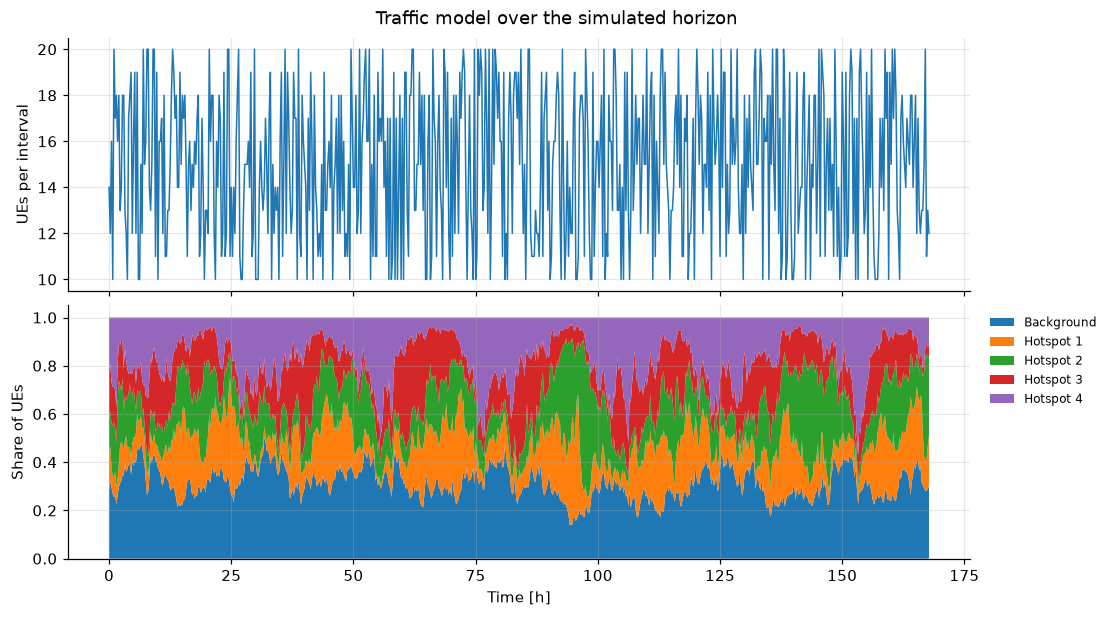

In [7]:
hours = np.asarray(manifest["time"]["t_s"]) / 3600.0
mass = np.asarray(manifest["time"]["component_mass"])

figure, axes = plt.subplots(2, 1, figsize=(10.0, 5.5), sharex=True, constrained_layout=True)
axes[0].plot(hours, manifest["time"]["count"], lw=1.0)
axes[0].set_ylabel("UEs per interval")
axes[1].stackplot(
    hours,
    mass.T,
    labels=["Background"] + [f"Hotspot {index + 1}" for index in range(mass.shape[1] - 1)],
)
axes[1].set(xlabel="Time [h]", ylabel="Share of UEs")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
figure.suptitle("Traffic model over the simulated horizon")
save_fig(figure, "traffic_model")
plt.show()

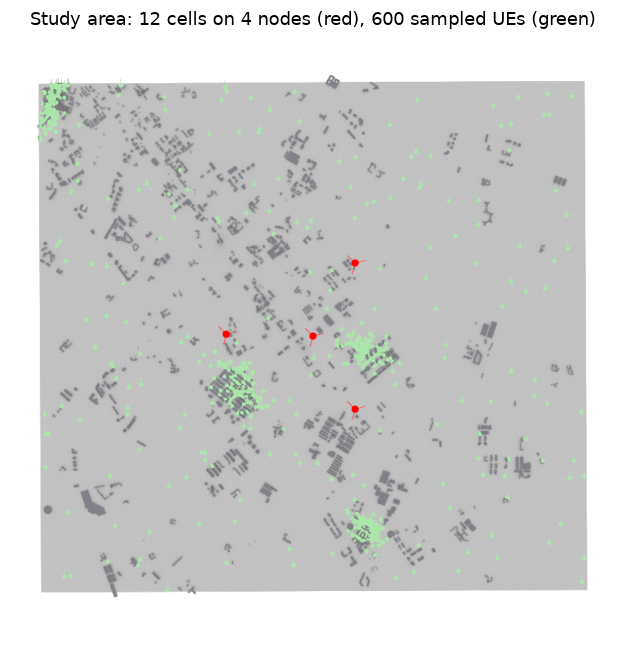

In [8]:
from sionna.rt import Receiver

from src.simulation import scene as scene_module

UE_RENDER_SAMPLE = 600

scene, bounds = scene_module.load(scene_module.SceneSpec.from_config(cfg))
transmitter.build(scene, cells, bands[0], float(cfg.simulation.antenna.power_rs))
sample = ue.sample(n=min(UE_RENDER_SAMPLE, len(ue)), random_state=cfg.seed)
for index, row in enumerate(sample.itertuples()):
    scene.add(Receiver(name=f"ue{index}", position=[row.x, row.y, row.z], display_radius=25.0))

figure = scene_module.render_top_down(
    scene,
    bounds,
    f"Study area: {len(cells)} cells on {len(nodes.drop_duplicates())} nodes (red), "
    f"{len(sample)} sampled UEs (green)",
    show_devices=True,
    show_orientations=True,
)
save_fig(figure, "study_area")
plt.show()
del scene

## 4. Radio Propagation Model

Radio propagation is simulated with **Sionna RT** over the 3D scene, one solve per band, with every
cell at its configured tilt. The radio-map solver records the mechanisms below.

In [9]:
rm = cfg.simulation.radio_map
rx_array = cfg.simulation.antenna.receiver
display(
    property_table(
        {
            "Maximum path depth": int(rm.max_depth),
            "Ray samples per transmitter": f"{int(rm.samples_per_tx):,}",
            "Line of sight": bool(rm.los),
            "Specular reflection": bool(rm.specular_reflection),
            "Diffuse reflection (scattering)": bool(rm.diffuse_reflection),
            "Refraction": bool(rm.refraction),
            "Diffraction": bool(rm.diffraction),
            "Edge diffraction": bool(rm.edge_diffraction),
            "Receiver antenna": f"{rx_array.num_rows}x{rx_array.num_cols} {rx_array.pattern}, "
            f"{rx_array.polarization} polarization",
            "Propagation materials": "Frequency-static (src/simulation/materials.py)",
            "Noise temperature [K]": float(rm.temperature),
        },
        "propagation_parameters",
    )
)

,Property,Value
0,Maximum path depth,8
1,Ray samples per transmitter,"10,000,000"
2,Line of sight,True
3,Specular reflection,True
4,Diffuse reflection (scattering),False
5,Refraction,True
6,Diffraction,False
7,Edge diffraction,False
8,Receiver antenna,"1x1 dipole, V polarization"
9,Propagation materials,Frequency-static (src/simulation/materials.py)


The solver's path gain is converted into reference-signal received power:

$$
P_{\mathrm{RX}}(g,c) = P_{\mathrm{TX}}(c) + G_{\mathrm{path}}(g,c) - L_{\mathrm{system}}(c),
$$

where $g$ is a grid tile, $c$ a cell-band pair, $P_{\mathrm{TX}}$ the per-resource-element
reference-signal power (`simulation.antenna.power_rs`), and $G_{\mathrm{path}}$ the ray-traced path
gain in dB including both antenna patterns. The implementation applies no additional system loss
($L_{\mathrm{system}} = 0$). A tile no ray reaches has no value (NaN) for that cell-band.

   b2600  tilt 12.0-12.0 deg     1.2s  tiles reached  88.1%  best server -234.5 to  -50.5 dBm
   b1800  tilt 10.0-10.0 deg     1.3s  tiles reached  87.8%  best server -214.2 to  -48.1 dBm
    b700  tilt  8.0- 8.0 deg     0.8s  tiles reached  91.1%  best server -201.4 to  -41.4 dBm


radio map: data\interim\radio_map.npz  shape (3, 12, 326, 310) [band, tx, row, col]


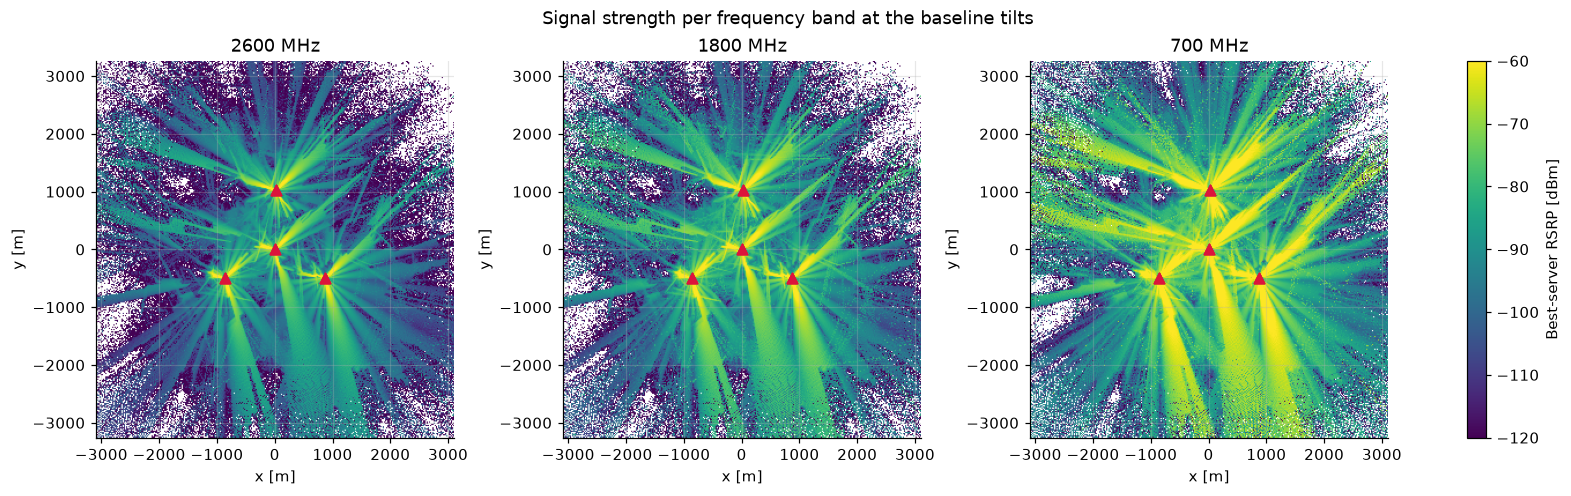

In [10]:
from src.evaluation import maps, plots
from src.kpi.capacity import max_rsrp
from src.simulation import radio

radio_map_file = radio.solve(cfg)
with np.load(radio_map_file, allow_pickle=False) as archive:
    radio_map = {key: archive[key] for key in archive.files}
rsrp = radio_map["rsrp_dbm"].astype(float)
sinr = radio_map["sinr_db"].astype(float)
best_per_band = {band: max_rsrp(rsrp[[index]]) for index, band in enumerate(bands)}

figure = plots.map_row(
    {label(band): best for band, best in best_per_band.items()},
    radio_map,
    colorbar_label="Best-server RSRP [dBm]",
    vmin=maps.RSRP_LIMITS[0],
    vmax=maps.RSRP_LIMITS[1],
    cells=nodes,
)
figure.suptitle("Signal strength per frequency band at the baseline tilts")
save_fig(figure, "rsrp_per_band")
plt.show()

In [11]:
reach = pd.DataFrame(
    [
        {
            "Band": label(band),
            "Tiles reached [%]": 100.0 * np.isfinite(best).mean(),
            "Median RSRP of reached tiles [dBm]": float(np.median(best[np.isfinite(best)])),
        }
        for band, best in best_per_band.items()
    ]
)
save_table(reach, "reach_per_band")
reach

,Band,Tiles reached [%],Median RSRP of reached tiles [dBm]
0,2600 MHz,88.0962,-101.5990
1,1800 MHz,87.7973,-94.2376
2,700 MHz,91.0815,-84.9948


## 5. UE Measurements

Two UE datasets come out of the simulation:

| Dataset | File | Rows | Used by |
|---|---|---|---|
| UE positions | `data/external/ue_positions.csv` | every drawn UE, per interval | the search and evaluation: the served ratio |
| MDT | `data/interim/mdt.csv` | the UEs the serving rule (Section 6) admits at the committed tilts, with `rsrp_dbm` | nothing yet; kept for later use |

A UE on a tile no cell reaches, or blocked by PRB limits, has nothing to report, so it is in the UE
positions but not in the MDT. `rsrp_dbm` is the serving cell-band's clean RSRP at the UE's tile; it is
kept for reference and plots, and no score reads it. The KPIs look the radio map up at each UE's tile.

Neither measurement noise, missing neighbour reports, reporting thresholds nor position uncertainty
is modelled.

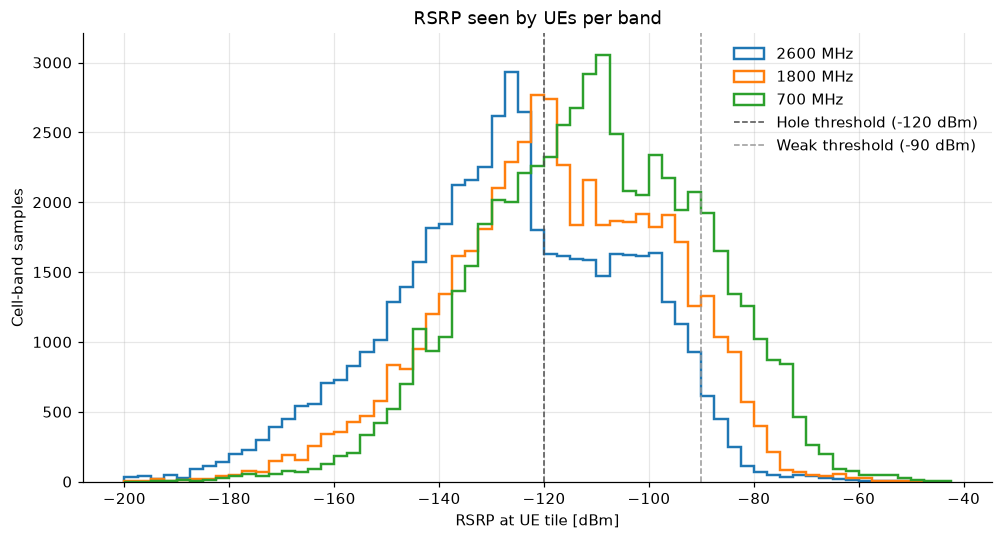

,Property,Value
0,UE rows,10087.0000
1,UEs with no path to any cell [%],17.4879
2,UEs at or below -120 dBm (incl. no path) [%],21.2353
3,Cell-band pairs per UE,36.0000


In [12]:
ue_rsrp = max_rsrp(rsrp)[ue["tile_row"].to_numpy(), ue["tile_col"].to_numpy()]
hole_dbm, weak_dbm = float(cfg.kpi.hole_dbm), float(cfg.kpi.weak_dbm)

figure, axis = plt.subplots(figsize=(9.0, 4.8), constrained_layout=True)
edges = np.arange(-200.0, -40.0, 2.5)
for index, band in enumerate(bands):
    values = rsrp[index][:, ue["tile_row"].to_numpy(), ue["tile_col"].to_numpy()].ravel()
    axis.hist(values[np.isfinite(values)], bins=edges, histtype="step", lw=1.6, label=label(band))
axis.axvline(hole_dbm, color="0.3", ls="--", lw=1, label=f"Hole threshold ({hole_dbm:g} dBm)")
axis.axvline(weak_dbm, color="0.6", ls="--", lw=1, label=f"Weak threshold ({weak_dbm:g} dBm)")
axis.set(
    xlabel="RSRP at UE tile [dBm]", ylabel="Cell-band samples", title="RSRP seen by UEs per band"
)
axis.legend()
save_fig(figure, "ue_rsrp_distribution")
plt.show()

display(
    property_table(
        {
            "UE rows": len(ue),
            "UEs with no path to any cell [%]": 100.0 * (~np.isfinite(ue_rsrp)).mean(),
            f"UEs at or below {hole_dbm:g} dBm (incl. no path) [%]": 100.0
            * (~(ue_rsrp > hole_dbm)).mean(),
            "Cell-band pairs per UE": rsrp.shape[0] * rsrp.shape[1],
        },
        "ue_measurement_summary",
    )
)

ue:  10087 rows
mdt: 5311 rows served (52.7%)  ->  data\interim\mdt.csv


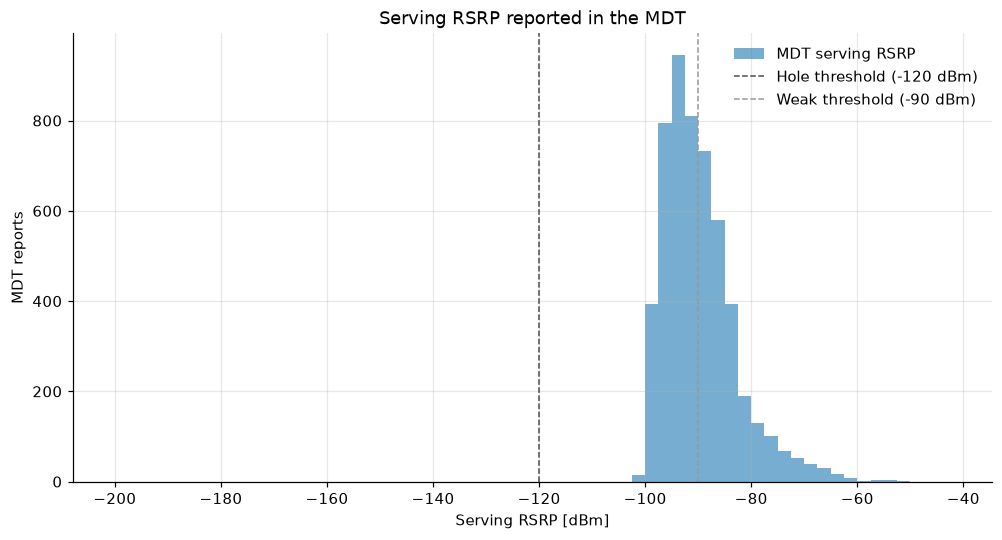

,Property,Value
0,UE position rows,10087.0000
1,MDT rows (served at the committed tilts),5311.0000
2,MDT share of UE rows [%],52.6519
3,Intervals with at least one MDT report,672.0000
4,Median MDT serving RSRP [dBm],-91.0280
5,Tiles with an MDT report,3017.0000
6,Reports on the busiest tile,15.0000


In [13]:
from src.simulation import mdt

mdt_file = mdt.build(cfg)
mdt_reports = pd.read_csv(mdt_file)

figure, axis = plt.subplots(figsize=(9.0, 4.8), constrained_layout=True)
axis.hist(mdt_reports["rsrp_dbm"], bins=edges, histtype="stepfilled", alpha=0.6, label="MDT serving RSRP")
axis.axvline(hole_dbm, color="0.3", ls="--", lw=1, label=f"Hole threshold ({hole_dbm:g} dBm)")
axis.axvline(weak_dbm, color="0.6", ls="--", lw=1, label=f"Weak threshold ({weak_dbm:g} dBm)")
axis.set(xlabel="Serving RSRP [dBm]", ylabel="MDT reports", title="Serving RSRP reported in the MDT")
axis.legend()
save_fig(figure, "mdt_rsrp_distribution")
plt.show()

display(
    property_table(
        {
            "UE position rows": len(ue),
            "MDT rows (served at the committed tilts)": len(mdt_reports),
            "MDT share of UE rows [%]": 100.0 * len(mdt_reports) / len(ue),
            "Intervals with at least one MDT report": mdt_reports["t_index"].nunique(),
            "Median MDT serving RSRP [dBm]": float(mdt_reports["rsrp_dbm"].median()),
            "Tiles with an MDT report": int(
                mdt_reports.groupby(["tile_row", "tile_col"]).ngroups
            ),
            "Reports on the busiest tile": int(
                mdt_reports.groupby(["tile_row", "tile_col"]).size().max()
            ),
        },
        "mdt_summary",
    )
)

## 6. Cell Selection Model

`src/kpi/capacity.py` assigns every UE, interval by interval, strongest RSRP first (over every layer at the UE; ties keep row order). Each UE ranks
its cell-bands: those at or above `kpi.capacity.rsrp_threshold_dbm` by band preference
(`kpi.capacity.band_preference`) then RSRP, followed by the rest by RSRP. Layers at or below
`kpi.hole_dbm` are never candidates. The UE takes the first cell-band still at or under
`max_admission_utilisation` of its `max_prb` with room for the PRBs its throughput needs
(Shannon rate at the tile's SINR). Before capacity, the rule reduces to

$$
s(g) = \underset{(i,b)\,:\,R_{i,b}(g) \ge T_{\mathrm{thr}}}{\arg\min}\;\bigl(\mathrm{rank}(b),\,-R_{i,b}(g)\bigr).
$$

Hysteresis, cell-selection offsets and mobility state are not modelled.

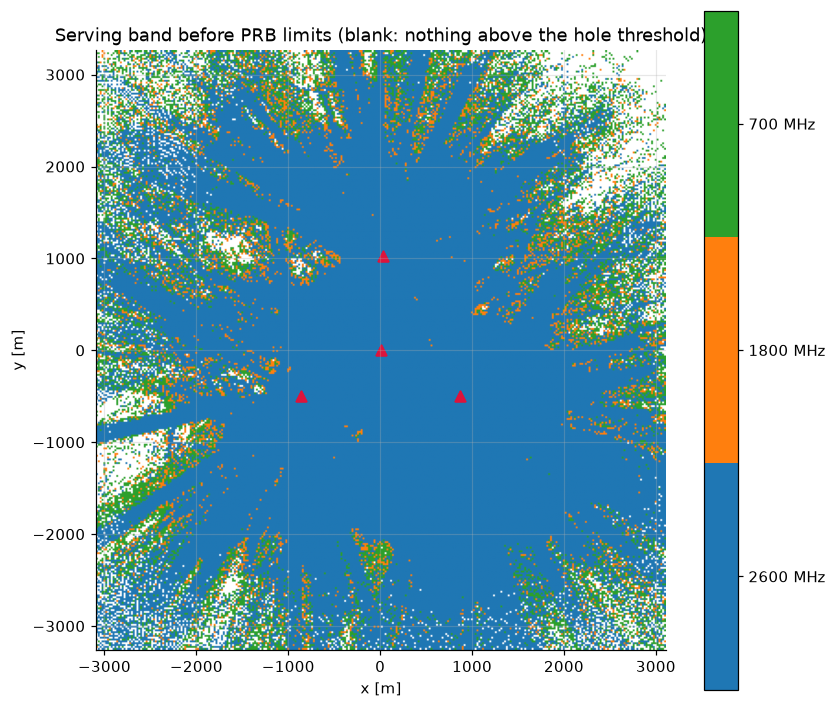

,Serving band,Share of UEs
0,2600 MHz,0.3408
1,1800 MHz,0.1050
2,700 MHz,0.0807
3,Not served,0.4735


In [14]:
from src.evaluation import compare
from src.kpi import capacity

spec = capacity.CapacitySpec.from_config(cfg, bands, len(cells))
serving = maps.serving_band(rsrp, spec.band_rank, spec.rsrp_threshold_dbm, spec.min_rsrp_dbm)
figure, axis = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
colours = plt.get_cmap("tab10")
image = axis.imshow(
    np.ma.masked_less(serving, 0),
    origin="lower",
    extent=maps.extent_of(radio_map),
    cmap=plt.matplotlib.colors.ListedColormap([colours(i) for i in range(len(bands))]),
    vmin=-0.5,
    vmax=len(bands) - 0.5,
)
bar = figure.colorbar(image, ax=axis, ticks=range(len(bands)))
bar.ax.set_yticklabels([label(band) for band in bands])
axis.scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson")
axis.set(xlabel="x [m]", ylabel="y [m]", title="Serving band before PRB limits (blank: nothing above the hole threshold)")
save_fig(figure, "serving_band_map")
plt.show()

served = capacity.serve_intervals(rsrp, sinr, bands, ue, cfg)
service = compare.service_summary(served, bands)
serving_mix = pd.DataFrame(
    [{"Serving band": label(band), "Share of UEs": service[f"share_{band}"]} for band in bands]
    + [{"Serving band": "Not served", "Share of UEs": service["not_served_share"]}]
)
save_table(serving_mix, "serving_band_mix")
serving_mix

## 7. Decision Variables and Constraints

The optimization variable is the absolute electrical tilt of every cell-band pair,
$\boldsymbol{\Theta} = \{\theta_{i,b}\}$, bounded per pair (`src/optim/space.py`, `TiltSpace`):

$$
\theta^{\min}_{i,b} \le \theta_{i,b} \le \theta^{\max}_{i,b}.
$$

The baseline $\theta^{(0)}_{i,b}$ is the committed `baseline_deg`. The current implementation has
**no** maximum-change constraint $|\theta - \theta^{(0)}| \le \Delta\theta^{\max}$ and **no** step
grid $\delta\theta$; the box is the only constraint.

In [15]:
from src.optim.space import TiltSpace

space = TiltSpace.from_config(cfg)
decision = pd.DataFrame(
    {
        "cell": [c for c, _ in space.pairs],
        "band": [b for _, b in space.pairs],
        "baseline": space.baseline,
        "lower": space.lower,
        "upper": space.upper,
    }
)
decision_summary = (
    decision.groupby("band", sort=False)
    .agg(
        pairs=("cell", "size"),
        baseline=("baseline", "median"),
        lower=("lower", "min"),
        upper=("upper", "max"),
    )
    .reset_index()
    .rename(
        columns={
            "band": "Band",
            "pairs": "Cell-band pairs",
            "baseline": "Baseline tilt [°]",
            "lower": "Minimum tilt [°]",
            "upper": "Maximum tilt [°]",
        }
    )
)
decision_summary["Band"] = decision_summary["Band"].map(label)
save_table(decision_summary, "decision_variables")
print(f"{space.n_dim} decision variables")
decision_summary

36 decision variables


,Band,Cell-band pairs,Baseline tilt [°],Minimum tilt [°],Maximum tilt [°]
0,2600 MHz,12,12.0,0.0,15.0
1,1800 MHz,12,10.0,0.0,15.0
2,700 MHz,12,8.0,0.0,15.0


## 8. Evaluation Metrics

Grid KPIs weight every tile equally ($w_g = 1$ over the whole grid $G$); only the served ratio counts
UEs, and it counts every UE position, in the search and in evaluation alike. The table below shows the
baseline. $R_{\mathrm{serv}}(g)$ is the strongest RSRP over all cell-bands,
$-\infty$ where no path exists. Thresholds come from `configs/kpi.yaml`.

**8.1 Coverage hole rate** (minimised)
$$
\mathrm{HoleRate} = \frac{1}{|G|}\sum_g \mathbb{1}\bigl[R_{\mathrm{serv}}(g) \le T_{\mathrm{hole}}\bigr]
$$

**8.2 Weak coverage rate** (minimised)
$$
\mathrm{WeakRate} = \frac{1}{|G|}\sum_g \mathbb{1}\bigl[T_{\mathrm{hole}} < R_{\mathrm{serv}}(g) \le T_{\mathrm{weak}}\bigr]
$$

**8.3 Co-band overlap rate** (minimised). On each band $b$ with strongest transmitter $s_b(g)$ above
$T_{\mathrm{hole}}$, a neighbour $j$ overlaps when $R_j(g) > T_{\mathrm{hole}}$ and
$R_{s_b}(g) - R_j(g) \le \Delta_R$. Summed over bands this gives $m_g$ (`overlap_neighbors`), and
$$
\mathrm{OverlapRate} = \frac{1}{|G|}\sum_g \mathbb{1}[m_g > 0].
$$

**8.4 Served UE ratio** (maximised): the share of all UE rows admitted to a cell-band by the serving
rule of Section 6. UEs with no path, or blocked by PRB limits, are not served.

**8.5 Cell-edge RSRP**: the 5th percentile of $R_{\mathrm{serv}}$ over covered tiles only
(3GPP TR 36.814 Annex A.2.1.4), read beside the hole rate.

**8.6 Objective** (ADR 0009)
$$
J = \frac{\sum_g w_g\, \lambda_g\, e^{1 - \lambda_g}}{\sum_g w_g},
\qquad \lambda_g = 1 + m_{b(g)}(g),
\qquad w_g = 1 + r_g
$$
$b(g)$ is the first band of `kpi.capacity.band_preference` whose strongest cell clears $T_{\mathrm{hole}}$, and
$m_{b(g)}$ is the 8.3 neighbour count **on that band alone**, not the summed $m_g$. So $\lambda_g$ is the number of
cells contending to serve the tile, and $\lambda_g = 0$ on a hole. $\lambda e^{1 - \lambda}$ peaks at exactly 1 when
$\lambda = 1$, giving 0.736 at 2 and 0.406 at 3, so the objective pays for one dominant server and nothing else.
$r_g$ is the tile's MDT reports over the busiest tile's, so $w_g \in [1, 2]$: demand doubles a tile at most and
silences none. $J \in [0, 1]$, maximised, with no free parameters.
The template's mean-overlap-neighbour count and band priority score are not project KPIs; the mean of
$m_g$ is shown below for reference only.

In [16]:
from src.kpi.overlap import overlap_neighbors
from src.optim import objective

# The objective is tile-uniform and reads no demand (ADR 0010).
kpis = objective.evaluate_kpis(rsrp, sinr, bands, ue, cfg)
neighbours = overlap_neighbors(rsrp, cfg)
baseline_kpis = pd.DataFrame(
    [
        *({"Measure": label(name), "Baseline": value} for name, value in kpis.as_dict().items()),
        {
            "Measure": "Mean co-band overlapping neighbours (reference)",
            "Baseline": float(neighbours.mean()),
        },
    ]
)
save_table(baseline_kpis, "baseline_kpis")
baseline_kpis

,Measure,Baseline
0,Coverage hole rate,0.1125
1,Co-band overlap rate,0.3164
2,Overlap neighbours per covered tile,0.9625
3,Weak coverage rate,0.3069
4,"Cell-edge RSRP, p05 [dBm]",-108.5644
5,"Median RSRP, p50 [dBm]",-84.1068
6,"Cell-edge SINR, p05 [dB]",-5.8729
7,"Median SINR, p50 [dB]",8.4932
8,Served UE rate,0.5265
9,Cell load imbalance (CoV),0.9098


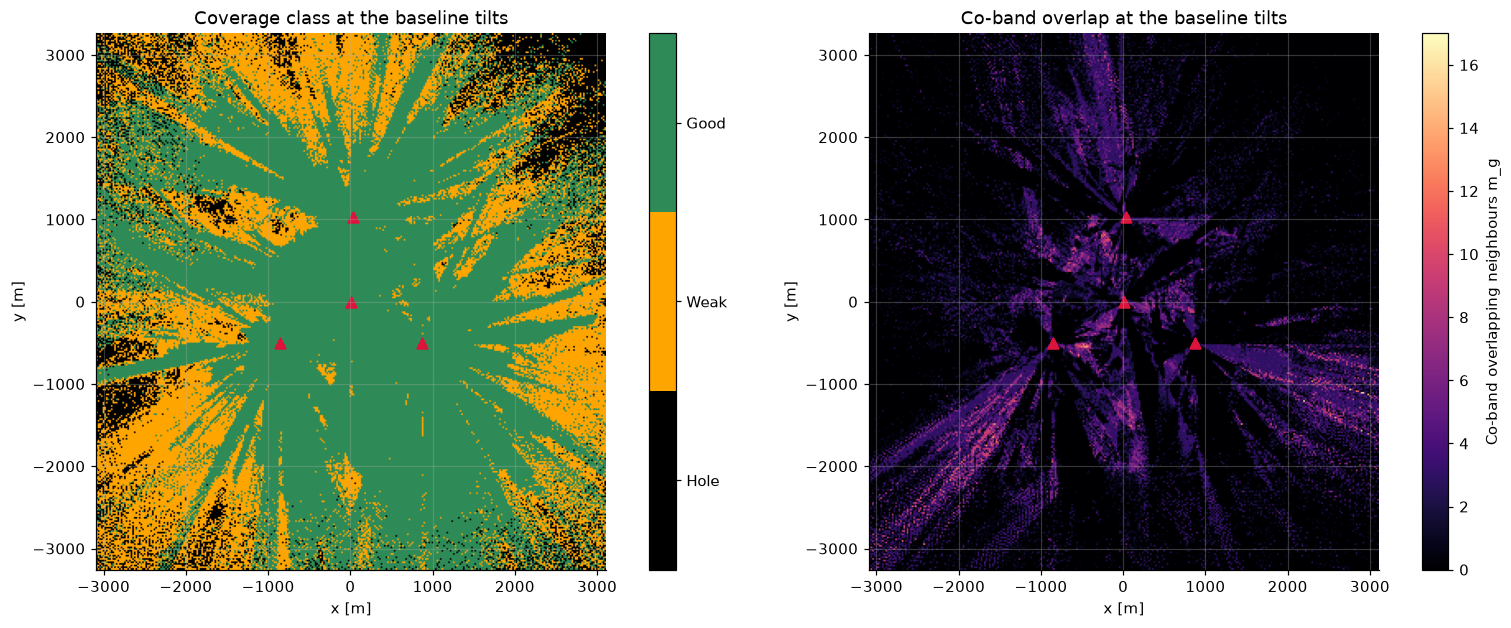

,coverage,tiles,tile_share,prb,demand_share
0,hole,11368,0.1125,0.0000e+00,0.000
1,weak,31017,0.3069,2.2406e+06,0.836
2,good,58675,0.5806,4.3944e+05,0.164


In [17]:
extent = maps.extent_of(radio_map)
figure, axes = plt.subplots(1, 2, figsize=(14.0, 5.6), constrained_layout=True)

classes = maps.coverage_class(rsrp, cfg)
image = axes[0].imshow(
    classes,
    origin="lower",
    extent=extent,
    cmap=plt.matplotlib.colors.ListedColormap(["black", "orange", "seagreen"]),
    vmin=-0.5,
    vmax=2.5,
)
bar = figure.colorbar(image, ax=axes[0], ticks=range(3))
bar.ax.set_yticklabels([name.capitalize() for name in maps.COVERAGE_CLASSES])
axes[0].set_title("Coverage class at the baseline tilts")

image = axes[1].imshow(neighbours, origin="lower", extent=extent, cmap="magma")
figure.colorbar(image, ax=axes[1], label="Co-band overlapping neighbours m_g")
axes[1].set_title("Co-band overlap at the baseline tilts")
for axis in axes:
    axis.scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson")
    axis.set(xlabel="x [m]", ylabel="y [m]")
save_fig(figure, "coverage_and_overlap_maps")
plt.show()

area_vs_demand = maps.coverage_table(rsrp, capacity.demand_prb(rsrp, sinr, bands, ue, cfg), cfg)
save_table(area_vs_demand, "coverage_by_area_and_demand")
area_vs_demand

## 9. Simulation Workflow

| # | Stage | Code |
|---|---|---|
| 1 | Load the 3D scene, cell table and antenna arrays | `src/simulation/scene.py`, `transmitter.py`, `radio.configure_arrays` |
| 2 | Raster open ground; draw hotspots, traffic and UE positions | `src/simulation/scenario.py` (`task simulation:scenario`) |
| 3 | Place cells at their per-band tilts and ray-trace every band | `src/simulation/radio.py` (`task simulation:radio`) |
| 4 | Convert path gain to RSRP and SINR per tile | `src/simulation/radio.py` |
| 4b | Serve every UE at the committed tilts; keep the served ones as MDT, for later use | `src/simulation/mdt.py` (`task simulation:mdt`) |
| 5 | Verify artifacts; write typed UE and cell tables | `src/data/build.py` (`task preprocess`, notebook 02) |
| 6 | Serve UEs; measure the KPIs and the objective | `src/kpi/`, `src/optim/objective.py` |
| 7 | Propose tilts, re-trace, re-measure on every UE until the budget is spent | `src/optim/run.py` (notebooks 03a, 03b) |
| 8 | Compare the best configurations with the baseline, over all UEs | `src/evaluation/run.py` (notebook 04) |

Stages 1–6 run in this notebook.

## 10. Experimental Configurations

### 10.1 Baseline

| Property | Description |
|---|---|
| Tilt configuration | Committed `baseline_deg` of every cell-band pair (Section 3.2) |
| Azimuths | Node fans rotated by `transmitters.layout.azimuth_offset_deg` |
| UE distribution | The fixed scenario drawn in Section 3.3, every UE kept and counted |
| Propagation settings | `simulation.radio_map`, identical for every configuration |
| Optimization | None |

## 11. Result Summary

The baseline column is the KPI table of Section 8. The optimized columns and their changes are
produced by notebook 04 from the runs of notebooks 03a and 03b; optimization runs from before this
configuration change are not comparable and must be rerun.

In [18]:
baseline_kpis

,Measure,Baseline
0,Coverage hole rate,0.1125
1,Co-band overlap rate,0.3164
2,Overlap neighbours per covered tile,0.9625
3,Weak coverage rate,0.3069
4,"Cell-edge RSRP, p05 [dBm]",-108.5644
5,"Median RSRP, p50 [dBm]",-84.1068
6,"Cell-edge SINR, p05 [dB]",-5.8729
7,"Median SINR, p50 [dB]",8.4932
8,Served UE rate,0.5265
9,Cell load imbalance (CoV),0.9098


## 12. Key Findings

Baseline: 2600 MHz at 12°, 1800 MHz at 10° and 700 MHz at 8° tilt on 25 m masts, fans rotated by the configured
azimuth offset.

* **Coverage.** 11.2% of grid tiles are coverage holes and 30.7% are weak, leaving 58.1% with good
  coverage. The weak class holds 83.6% of the PRB demand, while holes hold none: a UE with no candidate
  cell-band adds no PRB count.
* **Band reach.** 700 MHz reaches the most tiles (91.1%, median -85 dBm). 1800 MHz reaches 87.8% at -94 dBm and
  2600 MHz 88.1% at a median of -102 dBm, the weakest coverage layer.
* **Co-band overlap.** 31.6% of tiles have at least one co-band neighbour within 6 dB, with 0.96
  overlapping neighbours per covered tile on average.
* **Preferred-band use.** Band preference puts 34.1% of UEs on 2600 MHz, 10.5% on 1800 MHz and 8.1% on 700 MHz.
* **Service.** The served rate is 52.7% over all UEs. 17.5% of UEs have no path to any cell and 21.2% are
  at or below the hole threshold; the remaining unserved share (about 26 points) is refused by the 0.8
  admission ceiling under the placeholder capacity settings.
* **Load.** Peak PRB utilisation is 0.7999 - the admission ceiling exactly. The network is capacity-bound at the
  committed tilts, and cell load imbalance is 0.91.
* **MDT.** 5,311 of 10,087 UE rows (52.7%) are served at the baseline and form the MDT, with a median serving
  RSRP of -91 dBm and a median requirement of 53 PRBs per report. They land on 3,017 distinct tiles, the busiest
  carrying 15. The demand map notebook 02 builds is that count per tile; the objective weights each tile
  `w = 1 + r`, with `r` the tile's count over the busiest tile's, so a reported tile weighs between 1 and 2 and
  unreported ground still weighs 1. The search and evaluation count every UE.
* **Objective.** J = 0.8080 at the baseline (ADR 0009): the demand-weighted share of the grid served cleanly by
  exactly one cell, in [0, 1]. 66.1% of tiles are *effectively covered* - above -120 dBm on their serving band
  with no co-band cell within 6 dB - and those are the tiles worth the full 1.0. Unlike the KPIs beside it, J
  depends on the MDT as well as on the radio map, though on this scenario the weighting moves it by only 0.0005.
* **Trade-offs and per-cell changes** need an optimized configuration. They are reported by notebook 04.

## 13. Assumptions and Limitations

* The 3D scene and its frequency-static materials approximate the real environment.
* Antenna positions come from the layout generator and azimuths from a fixed offset, not a surveyed site plan.
* UE positions are independent per interval; there is no mobility or handover.
* RSRP is the clean ray-traced value at the tile centre; no measurement noise, report censoring or
  position error is modelled.
* SINR assumes full-load interference; throughput uses the Shannon rate without MCS tables.
* Capacity settings in `configs/kpi.yaml` are placeholders.
* Grid KPIs count area, including area without users.
* Simulation improvements must be validated with field measurements before operational deployment.

## 14. Conclusion

This notebook builds a reproducible scenario for multi-band tilt coordination: a fixed city, layout and
UE population, a ray-traced radio map at the baseline tilts, and the KPIs and objective every
optimizer is measured by. It supports engineering analysis and candidate selection; it does not replace
field validation or controlled network trials.